# 第9回 Python Seminar：QM9低分子の `gap_eV` 予測

配布された次の2ファイルだけを使い、SMILESから特徴量を作って `gap_eV` を予測します。

- `qm9_bandgap_train.csv`：学習用15,000件
- `qm9_bandgap_test_without_answer.csv`：予測対象4,000件

正式な評価指標は **MAE（Mean Absolute Error、単位eV）** です。値が小さいほど良いモデルです。

このNotebookは、第8回Notebookの構成を参考に、初心者が「何を考え、どこを変更するか」を追いやすいように作っています。外部データ、インターネット上の正解、LLM、NNP、事前学習済み分子モデルは使用しません。


## 1. 最初に確認するレギュレーション

- 使用データは、指定されたtrain CSVと正解なしtest CSVだけです。
- 評価はMAEで行います。
- モデルは配布trainから0から学習します。
- LLM・NNP・外部学習済みモデルを組み込みません。
- 最終候補は、Extra Trees、XGBoost、2モデルのアンサンブルの最大3系統です。
- testの正解は、特徴量・モデル・ハイパーパラメータ・混合比の選択に使いません。
- seedはスライドの推奨値である8に固定します。
- 提出は `smiles,gap_eV` の2列、4,000行です。

> **重要：** このNotebookで表示するCV MAEは、train内のout-of-fold予測による見積もりです。正解なしtestのMAEではありません。


## 2. 全体の流れ

1. 人間が検討する設定を確認する
2. CSVの行数・列・欠損・重複を検査する
3. SMILESを記述子とfingerprintへ変換する
4. 同一SMILESを分けない5-foldを作る
5. 各foldの学習部分だけで欠損補完を `fit` する
6. Extra TreesとXGBoostのOOF予測を作る
7. OOF MAEだけでアンサンブル比率と採用候補を決める
8. 全trainで再学習し、test 4,000件を予測する
9. `submission.csv` を保存して読み直し検査する
10. モデルと工夫点を約1分で説明できる形にまとめる


## 3. 人間が序盤で検討する項目

| 検討項目 | 調整後の設定 | 主な変更場所 | 初心者向けの見方 |
| --- | --- | --- | --- |
| 評価指標 | MAE（eV） | `TARGET`、評価セル | 小さいほど予測の平均的なずれが小さい |
| 乱数seed | 8 | `SEED` | 比較中は固定して条件をそろえる |
| 検証方法 | 目的値binをそろえたGroup 5-fold | `N_SPLITS` | 同じ分子を学習側と検証側に分けない |
| 特徴量方式 | `auto` | `FEATURE_MODE` | RDKitがなければ明示的fallbackを使う |
| fingerprint長 | 2,048 | `N_FINGERPRINT_FEATURES` | 長くすると情報量と計算量が増える |
| Morgan半径 | 2 | `MORGAN_RADIUS` | RDKit経路で使用する |
| SMILES n-gram | 1〜5文字 | `SMILES_NGRAM_RANGE` | fallback経路で使用する |
| Extra Trees | 600本、葉4件以上、bootstrap 80% | `EXTRA_PARAMS` | 葉を細かくしすぎず過学習を抑える |
| XGBoost | 1,000本、学習率0.03、lossguide、最大128葉 | `XGB_PARAMS` | 良い分割を優先し、小さな修正を積み重ねる |
| 混合比 | 0.00〜1.00を0.05刻み | `BLEND_WEIGHT_GRID` | OOF予測だけで決める |
| 最終候補 | OOF MAE最小 | モデル比較セル | fold間のばらつきも一緒に確認する |

### 今回行ったハイパーパラメータ調整

testの正解は使わず、固定したtrain内5-foldのOOF MAEだけで調整しました。最初に広めの候補を比較し、良かった範囲だけを細かく調べる順番にしています。

| モデル | 調整前のOOF MAE | 調整後のOOF MAE | 改善量 | 主に効いた変更 |
| --- | ---: | ---: | ---: | --- |
| Extra Trees | 0.466661 eV | 0.442752 eV | 0.023909 eV（約5.1%） | `min_samples_leaf=4`、bootstrap、各木80%抽出 |
| XGBoost | 0.307848 eV | 0.249353 eV | 0.058495 eV（約19.0%） | 深さ固定からlossguide・最大128葉へ変更し、1,000本まで学習 |

調整候補を大量に試しすぎると、同じCVへ偶然合う設定を選ぶ危険があります。そのため今回は、意味を説明できる主要項目に絞りました。testの正解が配布されても、その値を見て再調整しません。


## 3.1 初心者向け用語集

- **回帰**：`gap_eV` のような連続した数値を予測する問題です。
- **特徴量（X）**：モデルへ渡す予測材料です。分子量、原子数、部分構造などが該当します。
- **目的変数（y）**：モデルに当ててほしい答えです。今回は `gap_eV` です。
- **SMILES**：原子、結合、分岐、環などを1行の文字列で表した分子表現です。
- **分子記述子**：分子量や環数のように、分子全体の性質を数値化したものです。
- **fingerprint**：分子中の局所構造を固定長ベクトルへ変換したものです。
- **fit**：学習データから規則や代表値を学ぶ処理です。
- **predict**：学習済みモデルから新しい分子の予測値を出す処理です。
- **ハイパーパラメータ**：木の本数や深さなど、人間が学習前に決める設定です。
- **CV（交差検証）**：trainを複数組に分け、学習役と検証役を交代して性能を測る方法です。
- **fold**：CVで分けた1組です。
- **OOF予測**：各行を学習に使っていないモデルで予測した値です。
- **データリーク**：検証・test側でしか知り得ない情報が学習へ混ざることです。
- **アンサンブル**：複数モデルの予測を組み合わせる方法です。


## 3.2 実行環境とRDKitについて

このプロジェクトの実行に必要なライブラリは `uv add` で `pyproject.toml` と `uv.lock` へ追加しています。

現在の環境ではPyPIへのネットワーク接続が制限され、RDKitだけ新規取得できませんでした。そのためコードは次の2経路を持ちます。

1. **推奨経路**：RDKitがあれば、2D分子記述子 + Morgan fingerprintを使用
2. **検証済みfallback**：RDKitがなければ、SMILESから数えた構造特徴 + 文字n-gram hash fingerprintを使用

fallbackも指定された2つのCSVだけから特徴量を作り、外部データは使いません。ただし、化学構造のcanonical化やMorgan fingerprintではありません。ネットワーク利用可能な環境では、lesson_9内で `uv add rdkit` を実行してからNotebookを先頭から再実行すると、自動的に推奨経路へ切り替わります。


*〜 必要なライブラリと、評価・学習用の道具を読み込みます 〜*

**このセルで行うこと**

- **入力**：なし
- **処理**：CSV、配列、グラフ、疎行列、交差検証、MAE、2種類の回帰モデルに必要な道具を読み込みます
- **出力**：Pythonと主要ライブラリのバージョンを表示します

`import` は、別のライブラリに用意された道具をこのNotebookで使えるようにする命令です。


In [1]:
# ＊〜 必要なライブラリを読み込み、バージョンを確認します 〜＊

# ファイルの場所をOSに依存しない形で扱うPathを読み込む
from pathlib import Path
# SMILES中の原子記号を種類別に数えるCounterを読み込む
from collections import Counter
# RDKitが導入済みか調べる関数を読み込む
from importlib.util import find_spec
# 安全な一時フォルダを取得する関数を読み込む
from tempfile import gettempdir
# 特徴量作成や学習の所要時間を測る関数を読み込む
from time import perf_counter
# 環境変数を設定するためにosを読み込む
import os
# SMILESから原子記号を抽出する正規表現機能を読み込む
import re
# 実行中のPythonバージョン確認に使うsysを読み込む
import sys
# fallback使用時の注意を表示するwarningsを読み込む
import warnings

# Matplotlibがユーザーフォルダへ書き込まないよう、import前に一時保存先を指定
# Matplotlibの設定先が未指定の場合だけ一時フォルダを使う
os.environ.setdefault("MPLCONFIGDIR", str(Path(gettempdir()) / "lesson9-matplotlib"))

# グラフ描画用のpyplotをpltとして読み込む
import matplotlib.pyplot as plt
# 数値配列と計算に使うNumPyをnpとして読み込む
import numpy as np
# CSVと表データに使うpandasをpdとして読み込む
import pandas as pd
# DataFrameをNotebook上で見やすく表示する関数を読み込む
from IPython.display import display
# fingerprintを効率よく扱う疎行列機能を読み込む
from scipy import sparse
# 比較モデルのExtra Trees回帰器を読み込む
from sklearn.ensemble import ExtraTreesRegressor
# SMILESを固定長hash特徴量へ変換する機能を読み込む
from sklearn.feature_extraction.text import HashingVectorizer
# 記述子の欠損値を補完する機能を読み込む
from sklearn.impute import SimpleImputer
# 評価指標MAEを計算する関数を読み込む
from sklearn.metrics import mean_absolute_error
# 分布と分子groupを考慮してfoldを作る機能を読み込む
from sklearn.model_selection import StratifiedGroupKFold
# 主モデルのXGBoost回帰器を読み込む
from xgboost import XGBRegressor

# 表の列を最大100列まで省略せず表示する
pd.set_option("display.max_columns", 100)
# 全グラフに白背景とグリッドの共通スタイルを適用する
plt.style.use("seaborn-v0_8-whitegrid")

# 以下で再現性確認に必要な実行環境のバージョンを表示する
print(f"Python       : {sys.version.split()[0]}")
print(f"NumPy       : {np.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"scikit-learn: {__import__('sklearn').__version__}")
print(f"XGBoost     : {__import__('xgboost').__version__}")


Python       : 3.11.15
NumPy       : 2.4.6
pandas      : 3.0.3
scikit-learn: 1.9.0
XGBoost     : 3.2.0


*〜 ファイル、seed、CV、特徴量、モデルのハイパーパラメータを一か所にまとめます 〜*

**このセルで行うこと**

- **入力**：人間が決めた設定値
- **処理**：データの場所、再現用seed、fold数、特徴量、モデル、混合比を変数へ保存します
- **出力**：今回使用する主要設定を表示します

改善実験では主にこのセルを変更します。公平な比較のため、まずは一度に1項目だけ変えてください。


In [2]:
# ＊〜 実験条件とハイパーパラメータを一か所で管理します 〜＊

# 乱数を固定し、同じ条件で結果を再現できるようにする
SEED = 8
# 予測対象となる目的変数の列名を指定する
TARGET = "gap_eV"

# 学習CSVの相対パスを指定する
TRAIN_PATH = Path("qm9_bandgap_train.csv")
# 正解を含まないtest CSVの相対パスを指定する
TEST_PATH = Path("qm9_bandgap_test_without_answer.csv")
# 提出CSVの保存先を指定する
SUBMISSION_PATH = Path("submission.csv")
# 当日配布される場合の正解CSVの場所を指定する
ANSWER_PATH = Path("qm9_bandgap_test_with_answer.csv")

# cross-validationを5分割で行う
N_SPLITS = 5
# gap_eVを最大10層に分けてfold間の分布を揃えやすくする
N_TARGET_BINS = 10

# "auto" / "rdkit" / "string_fallback" から選ぶ
# RDKitがあれば使い、なければ文字列特徴量へ自動で切り替える
FEATURE_MODE = "auto"
# fingerprintまたはhash特徴量の列数を2048にする
N_FINGERPRINT_FEATURES = 2048
# Morgan fingerprintが見る原子近傍の半径を2にする
MORGAN_RADIUS = 2
# fallbackではSMILESの1〜5文字の並びを特徴量にする
SMILES_NGRAM_RANGE = (1, 5)

# Extra Treesの5-fold調整で選んだハイパーパラメータを辞書にまとめる
EXTRA_PARAMS = {
    # 木を600本作り、予測を平均してばらつきを抑える
    "n_estimators": 600,
    # 各分岐で全特徴量の85%を候補として使う
    "max_features": 0.85,
    # 1つの葉へ最低4件を残し、細かく分けすぎる過学習を抑える
    "min_samples_leaf": 4,
    # 元データから重複を許して行を抽出し、木ごとの差を作る
    "bootstrap": True,
    # 各木の学習にtrain foldの80%を使う
    "max_samples": 0.80,
    # 利用可能なCPUコアを使って木を並列に作る
    "n_jobs": -1,
}

# XGBoostの5-fold調整で選んだハイパーパラメータを辞書にまとめる
XGB_PARAMS = {
    # 小さい学習率で1,000本の木を順番に追加する
    "n_estimators": 1000,
    # lossguideでは深さを固定せず、葉の最大数で複雑さを制限する
    "max_depth": 0,
    # 損失を大きく減らす葉から優先して分割する
    "grow_policy": "lossguide",
    # 1本の木が持てる葉を最大128個にする
    "max_leaves": 128,
    # 1本ごとの修正量を3%に抑えて少しずつ学習する
    "learning_rate": 0.03,
    # 子ノードを作るために必要な重みの下限を2にする
    "min_child_weight": 2,
    # 各木では学習行の90%を使い、過学習を抑える
    "subsample": 0.90,
    # 各木では特徴量の90%を候補として使う
    "colsample_bytree": 0.90,
    # 葉の重みに小さなL1正則化を加える
    "reg_alpha": 0.02,
    # 葉の重みにL2正則化を加える
    "reg_lambda": 5.0,
    # 予測値と正解値の二乗誤差を学習時に小さくする
    "objective": "reg:squarederror",
    # 学習結果の表示・確認には課題指標のMAEを使う
    "eval_metric": "mae",
    # ヒストグラム方式で木を高速に作る
    "tree_method": "hist",
    # 利用可能なCPUコアを使う
    "n_jobs": -1,
}

# XGBoostの混合比を0.00〜1.00まで0.05刻みで用意する
BLEND_WEIGHT_GRID = np.round(np.arange(0.00, 1.001, 0.05), 2)

# 現在のseed・fold数・評価指標・特徴量数を表示する
print(
    f"seed={SEED}, CV={N_SPLITS} folds, metric=MAE (eV), "
    f"fingerprint={N_FINGERPRINT_FEATURES} features"
)


seed=8, CV=5 folds, metric=MAE (eV), fingerprint=2048 features


## 4. 指定されたデータの読み込みと安全確認

*〜 2つの指定CSVを相対パスから読み、列・行数・欠損・目的変数を検査します 〜*

**このセルで行うこと**

- **入力**：`qm9_bandgap_train.csv` と `qm9_bandgap_test_without_answer.csv`
- **処理**：ファイル、列、行数、欠損、有限な目的値を `assert` で検査します
- **出力**：表の大きさと先頭3行を表示します

`assert 条件` は、条件が正しくなければその場で停止する安全装置です。


In [3]:
# ＊〜 指定されたtrain/test CSVだけを読み込み、安全条件を検査します 〜＊

# 学習CSVがlesson_9フォルダに存在するか
assert TRAIN_PATH.exists(), f"学習CSVが見つかりません: {TRAIN_PATH}"
# test CSVがlesson_9フォルダに存在するか
assert TEST_PATH.exists(), f"テストCSVが見つかりません: {TEST_PATH}"

# 学習CSVをtrainというDataFrameへ読み込む
train = pd.read_csv(TRAIN_PATH)
# test CSVをtestというDataFrameへ読み込む
test = pd.read_csv(TEST_PATH)

# 学習データの列名と列順がsmiles, gap_eVになっているか
assert train.columns.tolist() == ["smiles", TARGET]
# testデータがsmiles列だけで、正解列を含まないか
assert test.columns.tolist() == ["smiles"]
# 学習データが課題指定の15,000行か
assert len(train) == 15_000
# testデータが課題指定の4,000行か
assert len(test) == 4_000
# 学習SMILESに欠損値がないか
assert train["smiles"].notna().all()
# test SMILESに欠損値がないか
assert test["smiles"].notna().all()
# 学習gap_eVに欠損値がないか
assert train[TARGET].notna().all()
# gap_eVがNaNや無限大を含まない有限の数値か
assert np.isfinite(train[TARGET].to_numpy(dtype=float)).all()
# testへ目的変数gap_eVが混入していないか
assert TARGET not in test.columns

# 読み込んだ学習データの行数と列数を表示する
print(f"train: {train.shape[0]:,} rows x {train.shape[1]} columns")
# 読み込んだtestデータの行数と列数を表示する
print(f"test : {test.shape[0]:,} rows x {test.shape[1]} columns")
print("指定データの安全確認: OK")
# 学習データの先頭3行を表で確認する
display(train.head(3))
# testデータの先頭3行を表で確認する
display(test.head(3))


train: 15,000 rows x 2 columns
test : 4,000 rows x 1 columns
指定データの安全確認: OK


,smiles,gap_eV
0,C#CC1(CNC1=O)C#C,7.094012
1,CC1CC=CCOC=N1,6.854552
2,CC1=C2CCC3C(C1)C23,5.839566


,smiles
0,CC1(CN1)C(C#C)C#N
1,C1CC11C2OC2C11CO1
2,OC1CC1C1CC(O)C1


*〜 欠損・重複・目的変数・SMILES長・F含有分子を集計します 〜*

**このセルで行うこと**

- **入力**：読み込んだtrainとtest
- **処理**：欠損、ユニーク数、重複、train/test重複、`gap_eV` 分布を数えます
- **出力**：品質確認表と目的変数の統計表を表示します

testにはFを含むSMILESがないため、通常MAEに加え、train内の非F行MAEも補助確認します。


In [4]:
# ＊〜 配布データの品質とtrain/testの分布差を数値で確認します 〜＊

# 学習SMILESを文字列型へ統一する
train_smiles = train["smiles"].astype(str)
# test SMILESを文字列型へ統一する
test_smiles = test["smiles"].astype(str)
# trainとtestで完全一致するSMILESの集合を求める
exact_overlap = set(train_smiles) & set(test_smiles)

# 行数・欠損・重複・F含有数・文字列長を比較表にまとめる
data_audit = pd.DataFrame(
    {
        "rows": [len(train), len(test)],
        "missing_cells": [int(train.isna().sum().sum()), int(test.isna().sum().sum())],
        "unique_smiles": [train_smiles.nunique(), test_smiles.nunique()],
        "duplicate_rows": [int(train.duplicated().sum()), int(test.duplicated().sum())],
        "contains_F": [
            int(train_smiles.str.contains("F", regex=False).sum()),
            int(test_smiles.str.contains("F", regex=False).sum()),
        ],
        "smiles_length_median": [
            float(train_smiles.str.len().median()),
            float(test_smiles.str.len().median()),
        ],
    },
    index=["train", "test"],
)

# gap_eVの平均・ばらつき・主要分位点を要約する
target_summary = train[TARGET].describe(
    percentiles=[0.05, 0.25, 0.50, 0.75, 0.95]
).to_frame("gap_eV").round(4)

# train/testの品質比較表を表示する
display(data_audit)
# gap_eVの要約統計量を表示する
display(target_summary)
# train/test間で完全一致するSMILES数を表示する
print(f"train/testの完全一致SMILES: {len(exact_overlap)}件")
# group分割の必要性を確認するため重複SMILES行数を表示する
print("train内の同一SMILES重複:", int(train_smiles.duplicated(keep=False).sum()), "行")


train/testの完全一致SMILES: 0件
train内の同一SMILES重複: 4 行


,rows,missing_cells,unique_smiles,duplicate_rows,contains_F,smiles_length_median
train,15000,0,14998,2,172,15.0
test,4000,0,4000,0,0,15.0


,gap_eV
count,15000.0000
mean,6.8239
std,1.2886
min,1.7742
5%,4.7266
25%,5.8858
50%,6.7811
75%,7.8342
95%,8.8682
max,10.7186


*〜 `gap_eV` 分布とSMILES文字列長をグラフで確認します 〜*

**このセルで行うこと**

- **入力**：trainの `gap_eV` と、train/testのSMILES長
- **処理**：ヒストグラムを左右2枚描きます
- **出力**：目的変数と入力文字列の分布を表示します


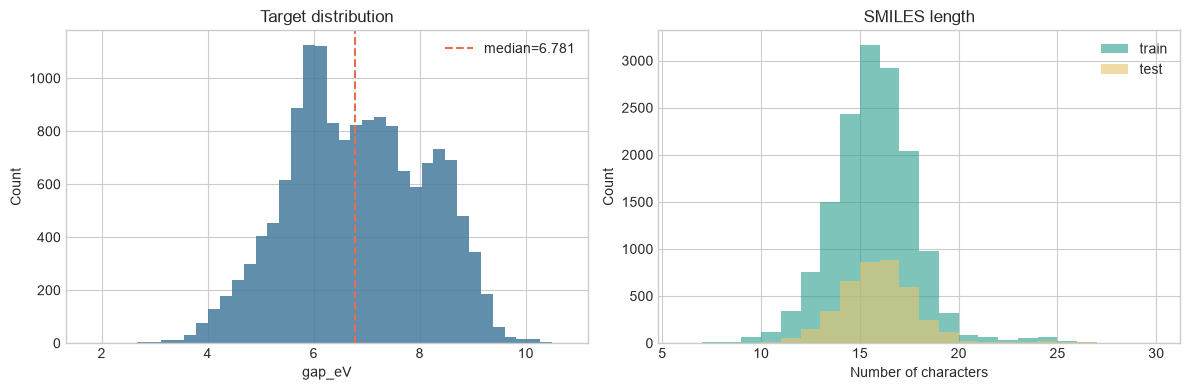

In [5]:
# ＊〜 目的変数とSMILES長の分布をグラフで可視化します 〜＊

# 横に2枚のグラフを置く描画領域を作る
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左側へgap_eVのヒストグラムを40区間で描く
axes[0].hist(train[TARGET], bins=40, color="#457b9d", alpha=0.85)
# gap_eVの中央値を破線で重ねる
axes[0].axvline(
    train[TARGET].median(),
    color="#e76f51",
    linestyle="--",
    label=f"median={train[TARGET].median():.3f}",
)
# 左側グラフのタイトルと軸名を設定する
axes[0].set(title="Target distribution", xlabel="gap_eV", ylabel="Count")
# 中央値の凡例を表示する
axes[0].legend()

# 右側へtrainのSMILES文字列長を描く
axes[1].hist(
    train_smiles.str.len(), bins=range(6, 31), alpha=0.60,
    label="train", color="#2a9d8f",
)
# 同じ右側へtestのSMILES文字列長を重ねる
axes[1].hist(
    test_smiles.str.len(), bins=range(6, 31), alpha=0.60,
    label="test", color="#e9c46a",
)
# 右側グラフのタイトルと軸名を設定する
axes[1].set(title="SMILES length", xlabel="Number of characters", ylabel="Count")
# trainとtestを見分ける凡例を表示する
axes[1].legend()

# グラフ要素が重ならないよう余白を調整する
plt.tight_layout()
# 完成した2枚のグラフを表示する
plt.show()


## 5. SMILESから特徴量を作る

*〜 RDKit経路とfallback経路の特徴量生成関数を定義します 〜*

**このセルで行うこと**

- **入力**：SMILES文字列
- **処理**：
  - RDKit経路では2D分子記述子とMorgan fingerprintを生成
  - fallback経路では明示的な構造カウントと文字n-gram hash fingerprintを生成
- **出力**：後のセルで呼び出せる関数を準備します

このセルは関数を定義するだけで、まだ全件の特徴量計算は行いません。


In [6]:
# ＊〜 SMILESを記述子とfingerprintへ変換する関数を定義します 〜＊

# SMILES中の主な原子記号を抽出する正規表現を準備する
ATOM_TOKEN_PATTERN = re.compile(r"Cl|Br|[BCNOFPSI]|[cnops]")


# RDKitなしで文字列特徴量を作る関数を定義する
def make_string_fallback_features(smiles_values):
    """RDKitがない場合に、SMILES文字列だけから安全な特徴量を作る。"""

    # 作成する20種類の記述子名を順番に定義する
    descriptor_names = [
        "smiles_length", "atom_token_count", "carbon_count",
        "nitrogen_count", "oxygen_count", "fluorine_count",
        "heteroatom_count", "aromatic_atom_count", "double_bond_count",
        "triple_bond_count", "branch_count", "ring_marker_count",
        "bracket_count", "charge_marker_count", "explicit_h_count",
        "carbonyl_pattern_count", "nitrile_pattern_count",
        "alkyne_pattern_count", "heteroatom_ratio", "aromatic_ratio",
    ]

    # 各分子の記述子を追加する空リストを作る
    descriptor_rows = []
    # SMILESを1分子ずつ取り出して記述子を計算する
    for smiles in smiles_values:
        # 現在のSMILESから原子記号を抽出する
        atom_tokens = ATOM_TOKEN_PATTERN.findall(smiles)
        # 抽出した原子を元素記号ごとに数える
        atom_counts = Counter(atom_tokens)
        # 比率計算で0除算しないよう原子数の下限を1にする
        n_atoms = max(len(atom_tokens), 1)

        # 脂肪族・芳香族を合わせた炭素数を求める
        n_carbon = atom_counts["C"] + atom_counts["c"]
        # 脂肪族・芳香族を合わせた窒素数を求める
        n_nitrogen = atom_counts["N"] + atom_counts["n"]
        # 脂肪族・芳香族を合わせた酸素数を求める
        n_oxygen = atom_counts["O"] + atom_counts["o"]
        # フッ素原子数を求める
        n_fluorine = atom_counts["F"]
        # 窒素・酸素・フッ素の合計を求める
        n_hetero = n_nitrogen + n_oxygen + n_fluorine
        # 小文字で表された芳香族原子数を求める
        n_aromatic = atom_counts["c"] + atom_counts["n"] + atom_counts["o"]

        # 1分子分の長さ・元素数・結合数・比率を追加する
        descriptor_rows.append(
            [
                len(smiles), len(atom_tokens), n_carbon, n_nitrogen,
                n_oxygen, n_fluorine, n_hetero, n_aromatic,
                smiles.count("="), smiles.count("#"), smiles.count("("),
                sum(character.isdigit() for character in smiles) / 2,
                smiles.count("["), smiles.count("+") + smiles.count("-"),
                atom_counts["H"], smiles.count("C=O") + smiles.count("C(=O)"),
                smiles.count("C#N"), smiles.count("C#C"),
                n_hetero / n_atoms, n_aromatic / n_atoms,
            ]
        )

    # 記述子リストを32bit数値配列へ変換する
    descriptors = np.asarray(descriptor_rows, dtype=np.float32)

    # SMILESの文字列パターンを2048次元のhash特徴量へ変換する器を作る
    vectorizer = HashingVectorizer(
        analyzer="char",
        ngram_range=SMILES_NGRAM_RANGE,
        n_features=N_FINGERPRINT_FEATURES,
        alternate_sign=False,
        binary=True,
        norm=None,
        lowercase=False,
        dtype=np.float32,
    )
    # 全SMILESを疎なhash特徴量行列へ変換する
    fingerprints = vectorizer.transform(smiles_values).tocsr()
    # 同じSMILESを同一foldへ置くためのgroup配列を作る
    group_smiles = np.asarray(smiles_values, dtype=object)
    # group・記述子・hash特徴量・列名を返す
    return group_smiles, descriptors, fingerprints, descriptor_names


# RDKitの化学記述子とMorgan fingerprintを作る関数を定義する
def make_rdkit_features(smiles_values):
    """RDKitの2D記述子とMorgan bit fingerprintを作る。"""

    # 分子読込とcanonical化に使うRDKit機能を読み込む
    from rdkit import Chem
    # 2D記述子とMorgan fingerprint生成機能を読み込む
    from rdkit.Chem import Descriptors, rdFingerprintGenerator

    # 全SMILESをRDKitの分子オブジェクトへ変換する
    molecules = [Chem.MolFromSmiles(smiles) for smiles in smiles_values]
    # 変換できなかったSMILESの行番号を集める
    invalid_indices = [i for i, molecule in enumerate(molecules) if molecule is None]
    # RDKitで解釈できないSMILESが1件もないか
    assert not invalid_indices, f"RDKitで読めないSMILES行: {invalid_indices[:10]}"

    # 表記違いの同一分子をまとめるためcanonical SMILESをgroupにする
    group_smiles = np.asarray(
        [Chem.MolToSmiles(molecule, canonical=True) for molecule in molecules],
        dtype=object,
    )

    # RDKitで使える2D記述子名と計算関数を取得する
    descriptor_definitions = list(Descriptors._descList)
    # 2D記述子の列名を計算順に取り出す
    descriptor_names = [name for name, _ in descriptor_definitions]

    # 各分子のRDKit記述子を追加する空リストを作る
    descriptor_rows = []
    # 分子を1つずつ取り出して全2D記述子を計算する
    for molecule in molecules:
        # 現在の1分子分の記述子を入れる空リストを作る
        row = []
        # 各記述子計算関数を順番に実行する
        for _, function in descriptor_definitions:
            try:
                # 記述子を計算して浮動小数点数へ変換する
                value = float(function(molecule))
                # 計算値がNaNまたは無限大かを確認する
                if not np.isfinite(value):
                    # 有限でない値を後で補完できるNaNへ統一する
                    value = np.nan
            # 個別の記述子計算に失敗しても全体処理を継続する
            except Exception:
                # 計算失敗箇所をNaNとして記録する
                value = np.nan
            # 計算した記述子を現在の分子の行へ追加する
            row.append(value)
        # 完成した1分子分の記述子を全体へ追加する
        descriptor_rows.append(row)
    # RDKit記述子を32bit数値配列へ変換する
    descriptors = np.asarray(descriptor_rows, dtype=np.float32)

    # 半径とbit数を指定してMorgan fingerprint生成器を作る
    fingerprint_generator = rdFingerprintGenerator.GetMorganGenerator(
        radius=MORGAN_RADIUS,
        fpSize=N_FINGERPRINT_FEATURES,
    )

    # 値が1になるfingerprintの行番号を入れるリストを作る
    row_indices = []
    # 値が1になるfingerprintのbit番号を入れるリストを作る
    column_indices = []
    # 各分子でONになったfingerprint bitを調べる
    for row_index, molecule in enumerate(molecules):
        # 現在の分子で値が1のbit番号を取得する
        on_bits = list(fingerprint_generator.GetFingerprint(molecule).GetOnBits())
        # ON bitの個数分だけ分子の行番号を追加する
        row_indices.extend([row_index] * len(on_bits))
        # ONになったbit番号を列番号リストへ追加する
        column_indices.extend(on_bits)

    # 行番号とbit番号からメモリ効率のよい疎行列を作る
    fingerprints = sparse.csr_matrix(
        (
            np.ones(len(row_indices), dtype=np.float32),
            (row_indices, column_indices),
        ),
        shape=(len(molecules), N_FINGERPRINT_FEATURES),
        dtype=np.float32,
    )
    # group・記述子・Morgan特徴量・列名を返す
    return group_smiles, descriptors, fingerprints, descriptor_names


*〜 利用可能な特徴量経路を選び、train/testの特徴量を実際に生成します 〜*

**このセルで行うこと**

- **入力**：train/testのSMILESと `FEATURE_MODE`
- **処理**：RDKitの有無を確認し、同じ方式でtrain/testを数値化します
- **出力**：有効な特徴量方式、記述子行列、fingerprint疎行列、groupを表示します

特徴量は各行のSMILESだけから決定論的に作ります。データから代表値を学ぶ欠損補完は、まだ行いません。


In [7]:
# ＊〜 特徴量方式を明示し、全19,000分子を数値特徴量へ変換します 〜＊

# 現在のuv環境でRDKitを読み込めるか自動判定する
RDKIT_AVAILABLE = find_spec("rdkit") is not None
# FEATURE_MODEが許可された3種類のいずれかか
assert FEATURE_MODE in {"auto", "rdkit", "string_fallback"}

# RDKitを明示指定した場合の処理へ分岐する
if FEATURE_MODE == "rdkit":
    # RDKit明示指定時にライブラリが導入済みか
    assert RDKIT_AVAILABLE, (
        "RDKitがありません。lesson_9で `uv add rdkit` を実行してください。"
    )
    # 実際に使う特徴量方式をRDKitへ確定する
    ACTIVE_FEATURE_MODE = "rdkit"
# 文字列fallback明示指定時の処理へ分岐する
elif FEATURE_MODE == "string_fallback":
    # 実際に使う方式を文字列fallbackへ確定する
    ACTIVE_FEATURE_MODE = "string_fallback"
# auto指定時の処理へ分岐する
else:
    # RDKitの有無に応じて実際の方式を選ぶ
    ACTIVE_FEATURE_MODE = "rdkit" if RDKIT_AVAILABLE else "string_fallback"

# 選ばれた方式に対応する特徴量作成関数を変数へ入れる
feature_function = (
    make_rdkit_features
    if ACTIVE_FEATURE_MODE == "rdkit"
    else make_string_fallback_features
)

# 特徴量作成時間の計測を始める
feature_start = perf_counter()
# train 15,000件からgroup・記述子・fingerprintを作る
groups, X_descriptors, X_fingerprints, descriptor_names = feature_function(
    train_smiles.tolist()
)
# test側のgroup・記述子・fingerprintを受け取る
(
    test_groups,
    X_test_descriptors,
    X_test_fingerprints,
    test_descriptor_names,
) = feature_function(test_smiles.tolist())

# trainとtestで記述子の列名と順序が一致するか
assert descriptor_names == test_descriptor_names
# train記述子の行数が15,000件と一致するか
assert X_descriptors.shape[0] == len(train)
# test記述子の行数が4,000件と一致するか
assert X_test_descriptors.shape[0] == len(test)
# train fingerprintが15,000行×2048列か
assert X_fingerprints.shape == (len(train), N_FINGERPRINT_FEATURES)
# test fingerprintが4,000行×2048列か
assert X_test_fingerprints.shape == (len(test), N_FINGERPRINT_FEATURES)

# 選択方式のgroupでtrain/testの重複を調べる
canonical_or_exact_overlap = set(groups) & set(test_groups)
# 特徴量作成にかかった秒数を計算する
feature_seconds = perf_counter() - feature_start

# 特徴量方式を説明用の読みやすい名称へ変換する
mode_label = {
    "rdkit": "RDKit 2D descriptors + Morgan fingerprint",
    "string_fallback": "SMILES count descriptors + character n-gram hash fingerprint",
}[ACTIVE_FEATURE_MODE]

# 選択された方式と特徴量行列の情報を以下で表示する
print(f"Feature mode       : {mode_label}")
print(f"RDKit available    : {RDKIT_AVAILABLE}")
print(f"Descriptor matrix  : {X_descriptors.shape}")
print(f"Fingerprint matrix : {X_fingerprints.shape}")
print(f"Train/test overlap : {len(canonical_or_exact_overlap)} groups")
print(f"Feature time       : {feature_seconds:.1f} sec")

# fallback使用時だけ注意メッセージを出す
if ACTIVE_FEATURE_MODE == "string_fallback":
    # RDKit特徴量ではないことを明示する警告を表示する
    warnings.warn(
        "RDKitがないためfallback特徴量を使用中です。"
        "化学構造のcanonical化とMorgan fingerprintは行っていません。"
    )


Feature mode       : SMILES count descriptors + character n-gram hash fingerprint
RDKit available    : False
Descriptor matrix  : (15000, 20)
Fingerprint matrix : (15000, 2048)
Train/test overlap : 0 groups
Feature time       : 0.3 sec


<ipython-input-1-9c1aa1eb4f9f>:79: UserWarning: RDKitがないためfallback特徴量を使用中です。化学構造のcanonical化とMorgan fingerprintは行っていません。
  warnings.warn(


## 6. 漏洩を防ぐ5-foldを固定する

*〜 目的変数の分布をそろえながら、同一groupを分けない5-foldを作ります 〜*

**このセルで行うこと**

- **入力**：`gap_eV` とcanonicalまたは完全一致SMILES group
- **処理**：目的値を10区間へ分け、Stratified Group 5-foldを作ります
- **出力**：foldごとの件数・目的値平均・F含有件数を表示します


In [8]:
# ＊〜 同一分子groupをまたがせない共通5-foldを作成・検査します 〜＊

# 目的変数gap_eVをNumPy配列へ変換する
y = train[TARGET].to_numpy(dtype=float)
# gap_eVを分位点に基づく最大10層へ分ける
target_bins = pd.qcut(y, q=N_TARGET_BINS, labels=False, duplicates="drop")

# 分布を保ちつつ同じ分子を分離しない5-fold分割器を作る
splitter = StratifiedGroupKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=SEED,
)
# 5-foldの学習行番号と検証行番号を確定する
fold_splits = list(
    splitter.split(X=np.zeros(len(train)), y=target_bins, groups=groups)
)

# 各行がどの検証foldに属するか記録する配列を作る
fold_id = np.zeros(len(train), dtype=int)
# foldごとの件数と分布を保存する空リストを作る
fold_summary_rows = []

# 5つのfoldを順に取り出して安全性と分布を確認する
for fold, (train_indices, valid_indices) in enumerate(fold_splits, start=1):
    # 同じ分子groupが学習側と検証側の両方へ入っていないか
    assert set(groups[train_indices]).isdisjoint(set(groups[valid_indices]))
    # 同じ行が複数の検証foldへ割り当てられていないか
    assert (fold_id[valid_indices] == 0).all()
    # 現在の検証行へ1〜5のfold番号を記録する
    fold_id[valid_indices] = fold

    # 現在foldの件数・gap_eV分布・F含有数を記録する
    fold_summary_rows.append(
        {
            "fold": fold,
            "train_rows": len(train_indices),
            "valid_rows": len(valid_indices),
            "valid_gap_mean": y[valid_indices].mean(),
            "valid_gap_std": y[valid_indices].std(),
            "valid_contains_F": int(
                train_smiles.iloc[valid_indices].str.contains("F", regex=False).sum()
            ),
        }
    )

# 学習全行がいずれか1つの検証foldへ割り当てられたか
assert (fold_id > 0).all()
# 作成されたfold数が指定した5個か
assert len(fold_splits) == N_SPLITS
# foldごとの件数と目的変数分布を表で表示する
display(pd.DataFrame(fold_summary_rows).round(4))


,fold,train_rows,valid_rows,valid_gap_mean,valid_gap_std,valid_contains_F
0,1,12000,3000,6.8183,1.2930,30
1,2,12000,3000,6.8273,1.2848,32
2,3,12000,3000,6.8230,1.2993,32
3,4,12000,3000,6.8239,1.2847,38
4,5,12000,3000,6.8269,1.2811,40


*〜 各foldの学習中央値だけを使う、最も単純なbaselineを評価します 〜*

**このセルで行うこと**

- **入力**：固定した5-foldと `gap_eV`
- **処理**：各検証foldへ、その学習側の中央値を予測します
- **出力**：baselineのOOF MAEを表示します


In [9]:
# ＊〜 学習fold中央値を予測するbaselineのOOF MAEを計算します 〜＊

# 全学習行のbaseline予測を保存する配列を作る
oof_baseline = np.empty(len(train), dtype=float)

# 各foldで学習側の情報だけを使ってbaseline予測する
for train_indices, valid_indices in fold_splits:
    # 現在の学習foldだけからgap_eV中央値を計算する
    fold_median = np.median(y[train_indices])
    # 検証fold全行へ学習fold中央値を予測値として入れる
    oof_baseline[valid_indices] = fold_median

# 全OOF予測と実測値からbaseline MAEを計算する
baseline_mae = mean_absolute_error(y, oof_baseline)
# baselineのOOF MAEをeV単位で表示する
print(f"Median baseline OOF MAE: {baseline_mae:.6f} eV")


Median baseline OOF MAE: 1.075058 eV


## 7. 2種類の回帰モデルを準備する

*〜 Extra TreesとXGBoostを同じ設定から毎回作る関数を定義します 〜*

**このセルで行うこと**

- **入力**：中央設定セルのハイパーパラメータとseed
- **処理**：新しい回帰モデルを返す関数を定義します
- **出力**：後のCVと最終学習で同じ設定を再利用できます

Extra Treesは記述子だけ、XGBoostは記述子とfingerprintの両方を使います。


In [10]:
# ＊〜 2種類のモデルを再現可能に生成する関数を定義します 〜＊

# 指定seedでExtra Treesを作る関数を定義する
def build_extra_trees(seed):
    """説明しやすい記述子を使うExtra Trees回帰モデルを返す。"""
    # 共通設定とseedを適用したExtra Trees回帰器を返す
    return ExtraTreesRegressor(**EXTRA_PARAMS, random_state=seed)


# 指定seedでXGBoostを作る関数を定義する
def build_xgboost(seed):
    """記述子とfingerprintを使うXGBoost回帰モデルを返す。"""
    # 共通設定とseedを適用したXGBoost回帰器を返す
    return XGBRegressor(**XGB_PARAMS, random_state=seed)


# 比較対象の基モデル名をリストで管理する
BASE_MODEL_NAMES = ["extra_trees", "xgboost"]
# 基モデルが予定どおり2個か
assert len(BASE_MODEL_NAMES) == 2
# 使用する基モデル名を表示する
print("Base models:", ", ".join(BASE_MODEL_NAMES))


Base models: extra_trees, xgboost


## 8. 5-fold cross-validationでOOF予測を作る

*〜 各fold内で欠損補完をfitし、2モデルのOOF予測とMAEを計算します 〜*

**このセルで行うこと**

- **入力**：固定fold、記述子、fingerprint、`gap_eV`
- **処理**：学習foldだけで補完器とモデルをfitし、検証foldを予測します
- **出力**：fold別MAE、全行のOOF予測、学習時間を表示します

このループがデータリーク防止の中心です。testはまだモデルへ入力しません。


In [11]:
# ＊〜 2モデルを5-foldで学習し、漏洩のないOOF予測を作ります 〜＊

# 全行のExtra Trees OOF予測を保存する配列を作る
oof_extra = np.empty(len(train), dtype=float)
# 全行のXGBoost OOF予測を保存する配列を作る
oof_xgb = np.empty(len(train), dtype=float)
# fold別のMAEと時間を保存する空リストを作る
fold_result_rows = []
# 5-fold cross-validation全体の時間計測を始める
cv_start = perf_counter()

# 共通5-foldで2モデルを順番に評価する
for fold, (train_indices, valid_indices) in enumerate(fold_splits, start=1):
    # 現在foldの時間計測を始める
    fold_start = perf_counter()

    # 欠損補完は必ず学習foldだけでfitする
    # 中央値補完器を作り、欠損があった列の印も追加する
    imputer = SimpleImputer(strategy="median", add_indicator=True)
    # 学習foldだけで補完値を学習し、学習記述子を変換する
    X_train_desc = imputer.fit_transform(X_descriptors[train_indices])
    # 学習foldで決めた補完値を検証記述子へ適用する
    X_valid_desc = imputer.transform(X_descriptors[valid_indices])

    # Extra Treesは記述子だけを使用
    # foldごとに固定seedのExtra Treesを作る
    extra_model = build_extra_trees(seed=SEED + fold)
    # Extra Treesを学習foldの記述子とgap_eVで学習する
    extra_model.fit(X_train_desc, y[train_indices])
    # 未学習の検証foldを予測してOOF位置へ保存する
    oof_extra[valid_indices] = extra_model.predict(X_valid_desc)

    # XGBoostは記述子とfingerprintを結合して使用
    # 学習foldの記述子とfingerprintを横に結合する
    X_train_combined = sparse.hstack(
        [
            sparse.csr_matrix(X_train_desc, dtype=np.float32),
            X_fingerprints[train_indices],
        ],
        format="csr",
        dtype=np.float32,
    )
    # 検証foldの記述子とfingerprintを同じ列順で結合する
    X_valid_combined = sparse.hstack(
        [
            sparse.csr_matrix(X_valid_desc, dtype=np.float32),
            X_fingerprints[valid_indices],
        ],
        format="csr",
        dtype=np.float32,
    )

    # foldごとに固定seedのXGBoostを作る
    xgb_model = build_xgboost(seed=SEED + fold)
    # XGBoostを学習foldの結合特徴量とgap_eVで学習する
    xgb_model.fit(X_train_combined, y[train_indices], verbose=False)
    # 未学習の検証foldを予測してOOF位置へ保存する
    oof_xgb[valid_indices] = xgb_model.predict(X_valid_combined)

    # 現在foldのExtra Trees MAEを計算する
    extra_mae = mean_absolute_error(y[valid_indices], oof_extra[valid_indices])
    # 現在foldのXGBoost MAEを計算する
    xgb_mae = mean_absolute_error(y[valid_indices], oof_xgb[valid_indices])
    # 現在foldにかかった秒数を計算する
    fold_seconds = perf_counter() - fold_start

    # 現在foldの2モデル分の結果を表用リストへ追加する
    fold_result_rows.extend(
        [
            {"model": "extra_trees", "fold": fold, "mae_eV": extra_mae,
             "seconds": fold_seconds},
            {"model": "xgboost", "fold": fold, "mae_eV": xgb_mae,
             "seconds": fold_seconds},
        ]
    )

    # 現在foldの2モデルのMAEと処理時間を表示する
    print(
        f"fold {fold}: Extra Trees MAE={extra_mae:.5f}, "
        f"XGBoost MAE={xgb_mae:.5f}, time={fold_seconds:.1f}s"
    )

# 5-fold全体にかかった秒数を計算する
cv_seconds = perf_counter() - cv_start
# Extra TreesのOOF予測が全行で有限の数値か
assert np.isfinite(oof_extra).all()
# XGBoostのOOF予測が全行で有限の数値か
assert np.isfinite(oof_xgb).all()

# fold別結果を比較しやすいDataFrameへ変換する
fold_results = pd.DataFrame(fold_result_rows)
# cross-validation全体の時間を表示する
print(f"Total CV time: {cv_seconds:.1f} sec")


fold 1: Extra Trees MAE=0.44304, XGBoost MAE=0.25020, time=34.2s
fold 2: Extra Trees MAE=0.44041, XGBoost MAE=0.24522, time=37.3s
fold 3: Extra Trees MAE=0.43385, XGBoost MAE=0.24582, time=36.7s
fold 4: Extra Trees MAE=0.44999, XGBoost MAE=0.25233, time=37.8s
fold 5: Extra Trees MAE=0.44647, XGBoost MAE=0.25320, time=35.1s
Total CV time: 181.2 sec


*〜 単体2モデルとアンサンブルをOOF MAEで比較し、採用候補を決めます 〜*

**このセルで行うこと**

- **入力**：Extra TreesとXGBoostのOOF予測
- **処理**：XGBoostの重みを0〜1で比較し、OOF MAEが最小の混合比を選びます
- **出力**：最大3候補のMAE、fold平均・標準偏差、非F部分MAE、採用候補を表示します


In [12]:
# ＊〜 OOF予測だけでアンサンブル比率と最終候補を選びます 〜＊

# 各混合比のOOF MAEを保存する空リストを作る
blend_rows = []
# 用意したXGBoost混合比を1つずつ試す
for xgb_weight in BLEND_WEIGHT_GRID:
    # 2モデルのOOF予測を現在の比率で加重平均する
    blended_prediction = (
        xgb_weight * oof_xgb + (1.0 - xgb_weight) * oof_extra
    )
    # 現在の混合比とOOF MAEを記録する
    blend_rows.append(
        {
            "xgb_weight": xgb_weight,
            "mae_eV": mean_absolute_error(y, blended_prediction),
        }
    )

# 混合比ごとの結果をDataFrameへ変換する
blend_table = pd.DataFrame(blend_rows)
# OOF MAEが最小の混合比の行を選ぶ
best_blend_row = blend_table.loc[blend_table["mae_eV"].idxmin()]
# 最良行からXGBoostの重みを取り出す
best_xgb_weight = float(best_blend_row["xgb_weight"])

# 選んだ重みでアンサンブルOOF予測を作る
oof_ensemble = (
    best_xgb_weight * oof_xgb + (1.0 - best_xgb_weight) * oof_extra
)

# testに近い条件を補助確認するため非F分子を選ぶ
non_f_mask = ~train_smiles.str.contains("F", regex=False).to_numpy()
# 比較する3候補とOOF予測を辞書にまとめる
candidate_oof = {
    "extra_trees": oof_extra,
    "xgboost": oof_xgb,
    "ensemble": oof_ensemble,
}

# 候補ごとの全体・fold別・非F MAEを保存する
comparison_rows = []
# 3候補を同じ基準で順番に評価する
for model_name, prediction in candidate_oof.items():
    # 現在候補の5つのfold別MAEを計算する
    fold_maes = [
        mean_absolute_error(y[fold_id == fold], prediction[fold_id == fold])
        for fold in range(1, N_SPLITS + 1)
    ]
    # 現在候補の評価結果を比較表用リストへ追加する
    comparison_rows.append(
        {
            "model": model_name,
            "oof_mae_eV": mean_absolute_error(y, prediction),
            "fold_mae_mean": np.mean(fold_maes),
            "fold_mae_std": np.std(fold_maes, ddof=1),
            "non_F_oof_mae_eV": mean_absolute_error(
                y[non_f_mask], prediction[non_f_mask]
            ),
        }
    )

# median baselineの5つのfold別MAEを計算する
baseline_fold_maes = [
    mean_absolute_error(y[fold_id == fold], oof_baseline[fold_id == fold])
    for fold in range(1, N_SPLITS + 1)
]
# median baselineの評価結果を比較表へ追加する
comparison_rows.append(
    {
        "model": "median_baseline",
        "oof_mae_eV": baseline_mae,
        "fold_mae_mean": np.mean(baseline_fold_maes),
        "fold_mae_std": np.std(baseline_fold_maes, ddof=1),
        "non_F_oof_mae_eV": mean_absolute_error(
            y[non_f_mask], oof_baseline[non_f_mask]
        ),
    }
)

# 候補をOOF MAEの小さい順に並べた表を作る
comparison_table = (
    pd.DataFrame(comparison_rows)
    .set_index("model")
    .sort_values("oof_mae_eV")
)

# baseline以外でOOF MAEが最小の候補名を選ぶ
selected_model_name = (
    comparison_table.drop(index="median_baseline")["oof_mae_eV"].idxmin()
)
# 採用候補に対応するOOF予測を取り出す
selected_oof_prediction = candidate_oof[selected_model_name]
# 採用候補の全学習行OOF MAEを計算する
selected_oof_mae = mean_absolute_error(y, selected_oof_prediction)

# モデル比較結果を小数6桁で表示する
display(comparison_table.round(6))
# OOFだけで選んだ最良のXGBoost混合比を表示する
print(f"Best ensemble XGBoost weight: {best_xgb_weight:.2f}")
# 最終学習に採用する候補名を表示する
print(f"Selected candidate: {selected_model_name}")
# 採用候補のOOF MAEをeV単位で表示する
print(f"Selected OOF MAE: {selected_oof_mae:.6f} eV")


Best ensemble XGBoost weight: 1.00
Selected candidate: xgboost
Selected OOF MAE: 0.249353 eV


,oof_mae_eV,fold_mae_mean,fold_mae_std,non_F_oof_mae_eV
model,,,,
xgboost,0.249353,0.249353,0.003671,0.249083
ensemble,0.249353,0.249353,0.003671,0.249083
extra_trees,0.442752,0.442752,0.006147,0.443185
median_baseline,1.075058,1.075058,0.003883,1.068579


*〜 採用候補の予測値と残差をグラフで確認します 〜*

**このセルで行うこと**

- **入力**：実測 `gap_eV` と採用候補のOOF予測
- **処理**：予測対実測の散布図と残差ヒストグラムを描きます
- **出力**：過大・過小予測や苦手な領域を目視できます


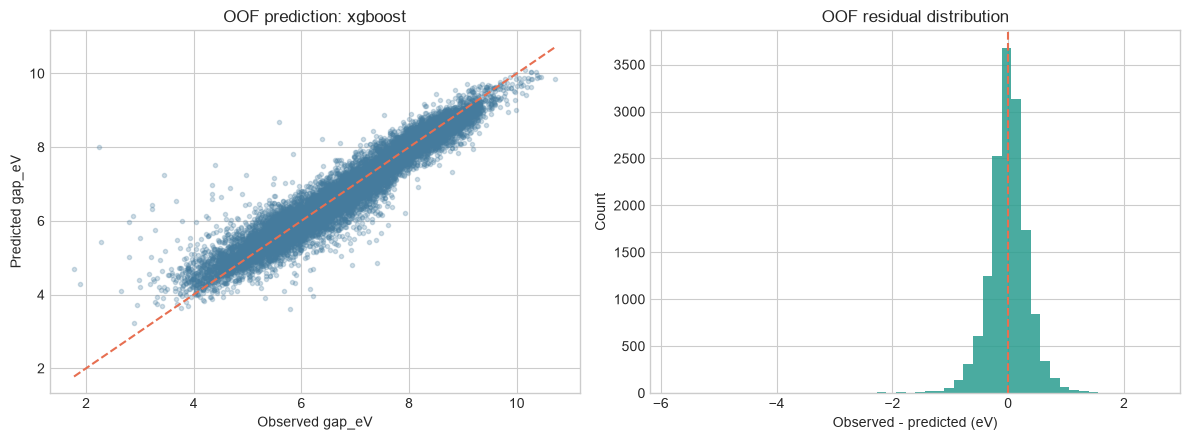

In [13]:
# ＊〜 採用候補のOOF予測と誤差の傾向を可視化します 〜＊

# 実測値からOOF予測値を引いて残差を求める
residuals = y - selected_oof_prediction
# 予測散布図と残差分布を横に並べる領域を作る
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 左側へ実測値とOOF予測値の散布図を描く
axes[0].scatter(
    y, selected_oof_prediction, s=9, alpha=0.25, color="#457b9d"
)
# 実測値と予測値を含むグラフ下限を求める
plot_min = min(y.min(), selected_oof_prediction.min())
# 実測値と予測値を含むグラフ上限を求める
plot_max = max(y.max(), selected_oof_prediction.max())
# 完全予測なら点が並ぶy=xの基準線を描く
axes[0].plot(
    [plot_min, plot_max], [plot_min, plot_max],
    linestyle="--", color="#e76f51",
)
# 左側グラフのタイトルと軸名を設定する
axes[0].set(
    title=f"OOF prediction: {selected_model_name}",
    xlabel="Observed gap_eV",
    ylabel="Predicted gap_eV",
)

# 右側へ残差のヒストグラムを50区間で描く
axes[1].hist(residuals, bins=50, color="#2a9d8f", alpha=0.85)
# 予測誤差ゼロの位置へ基準線を引く
axes[1].axvline(0, color="#e76f51", linestyle="--")
# 右側グラフのタイトルと軸名を設定する
axes[1].set(
    title="OOF residual distribution",
    xlabel="Observed - predicted (eV)",
    ylabel="Count",
)

# 2枚のグラフが重ならないよう余白を調整する
plt.tight_layout()
# 完成した予測・残差グラフを表示する
plt.show()


## 9. このコードで工夫したところ

1. **同一分子のfold漏洩を防止**：RDKit利用時はcanonical SMILES、fallback時は完全一致SMILESをgroupにします。
2. **目的変数分布をそろえた5-fold**：`gap_eV` を10個の分位binへ分けます。
3. **欠損補完をfold内だけでfit**：検証・testの値から中央値を作りません。
4. **大域特徴と局所特徴を分担**：記述子とfingerprintを併用します。
5. **異なるモデルの予測を組み合わせる**：OOF予測だけで混合比を決めます。
6. **test特有のF分布差を補助評価**：全体MAEと非F部分MAEを確認します。
7. **環境差を隠さない**：実際の特徴量方式を表示し、fallbackをMorganとは呼びません。
8. **提出事故をassertで防ぐ**：行数、列順、SMILES順、有限値、保存後CSVを検査します。\n9. **粗い探索から細かい探索へ進む**：train内OOF MAEだけで候補を絞り、上位設定を正式な5-foldで再確認します。


## 10. 全trainで再学習し、testを予測する

*〜 OOFで設計を決めた2モデルを全15,000件でfitし、test 4,000件を予測します 〜*

**このセルで行うこと**

- **入力**：全train特徴量・目的値、test特徴量、CVで決めた設定
- **処理**：補完器と2モデルを全trainで学習し、test予測とアンサンブル予測を作ります
- **出力**：候補別のtest予測範囲と学習時間を表示します

ここから初めてtest特徴量をモデルへ入力します。


In [14]:
# ＊〜 全trainで2モデルを再学習し、test 4,000件の予測を作ります 〜＊

# 全trainでの最終学習時間の計測を始める
final_start = perf_counter()

# 全train用の中央値補完器を新しく作る
final_imputer = SimpleImputer(strategy="median", add_indicator=True)
# 全train記述子だけで補完値を学習して変換する
X_full_desc = final_imputer.fit_transform(X_descriptors)
# trainで決めた補完値をtest記述子へ適用する
X_test_desc = final_imputer.transform(X_test_descriptors)

# 最終予測用のExtra Treesを固定seedで作る
final_extra_model = build_extra_trees(seed=SEED)
# Extra Treesを全trainで学習する
final_extra_model.fit(X_full_desc, y)
# 学習済みExtra Treesでtest 4,000件を予測する
extra_test_prediction = final_extra_model.predict(X_test_desc)

# 全trainの記述子とfingerprintを横に結合する
X_full_combined = sparse.hstack(
    [sparse.csr_matrix(X_full_desc, dtype=np.float32), X_fingerprints],
    format="csr",
    dtype=np.float32,
)
# testの記述子とfingerprintを同じ列順で結合する
X_test_combined = sparse.hstack(
    [sparse.csr_matrix(X_test_desc, dtype=np.float32), X_test_fingerprints],
    format="csr",
    dtype=np.float32,
)

# 最終予測用XGBoostを固定seedで作る
final_xgb_model = build_xgboost(seed=SEED)
# XGBoostを全trainの結合特徴量で学習する
final_xgb_model.fit(X_full_combined, y, verbose=False)
# 学習済みXGBoostでtest 4,000件を予測する
xgb_test_prediction = final_xgb_model.predict(X_test_combined)

# OOFで決めた混合比を変えずtest予測へ適用する
ensemble_test_prediction = (
    best_xgb_weight * xgb_test_prediction
    + (1.0 - best_xgb_weight) * extra_test_prediction
)

# 3候補のtest予測をモデル名と対応させる
candidate_test_predictions = {
    "extra_trees": extra_test_prediction,
    "xgboost": xgb_test_prediction,
    "ensemble": ensemble_test_prediction,
}
# OOFで採用した候補のtest予測を提出用に選ぶ
final_test_prediction = candidate_test_predictions[selected_model_name]

# 3候補の予測件数・有限値・範囲を確認する
for model_name, prediction in candidate_test_predictions.items():
    # 現在候補の予測件数がtest 4,000件と一致するか
    assert len(prediction) == len(test)
    # 現在候補の予測にNaNや無限大がないか
    assert np.isfinite(prediction).all()
    # 現在候補の予測最小値・中央値・最大値を表示する
    print(
        f"{model_name:12s}: min={prediction.min():.4f}, "
        f"median={np.median(prediction):.4f}, max={prediction.max():.4f}"
    )

# 最終学習とtest予測にかかった秒数を計算する
final_seconds = perf_counter() - final_start
# 最終学習時間を表示する
print(f"Final training time: {final_seconds:.1f} sec")


extra_trees : min=4.2149, median=6.6462, max=9.3498
xgboost     : min=3.6087, median=6.7892, max=9.9357
ensemble    : min=3.6087, median=6.7892, max=9.9357
Final training time: 35.8 sec


## 11. `submission.csv` を保存・検査する

*〜 `smiles,gap_eV` の2列を元test順で保存し、実ファイルを読み直して検査します 〜*

**このセルで行うこと**

- **入力**：元testのSMILESと採用候補の予測値
- **処理**：提出表を作成し、4,000行・列順・SMILES順・有限値を検査して保存します
- **出力**：`submission.csv` と、その先頭5行を表示します


In [15]:
# ＊〜 規定形式のsubmission.csvを作り、保存後の内容まで検査します 〜＊

# 提出DataFrameを同じ基準で検査する関数を定義する
def validate_submission(submission_frame):
    """提出表が規定の形式かをassertで検査する。"""

    # 列名と列順がsmiles, gap_eVになっているか
    assert submission_frame.columns.tolist() == ["smiles", TARGET]
    # 提出行数がtestと同じ4,000件か
    assert len(submission_frame) == len(test) == 4_000
    # SMILESの内容と順序が元のtestから変わっていないか
    assert submission_frame["smiles"].equals(test["smiles"])
    # 予測列gap_eVが数値型か
    assert pd.api.types.is_numeric_dtype(submission_frame[TARGET])
    # 予測列にNaNや無限大がないか
    assert np.isfinite(submission_frame[TARGET].to_numpy(dtype=float)).all()


# 元のtestを変えずSMILES列だけの提出表をコピーする
submission = test[["smiles"]].copy()
# 採用モデルのtest予測をgap_eV列として追加する
submission[TARGET] = np.asarray(final_test_prediction, dtype=float)

# 保存前の提出表がすべての規定を満たすか
validate_submission(submission)
# 行番号を付けずsubmission.csvとして保存する
submission.to_csv(SUBMISSION_PATH, index=False)

# 保存したCSVをもう一度読み戻す
saved_submission = pd.read_csv(SUBMISSION_PATH)
# 保存・読込後にも列・行数・順序・数値が正しいか
validate_submission(saved_submission)

# 保存先・行数・採用モデル名を表示する
print(
    f"OK: {SUBMISSION_PATH} "
    f"({len(saved_submission):,} rows, model={selected_model_name})"
)
# 完成した提出CSVの先頭5行を表示する
display(saved_submission.head())


OK: submission.csv (4,000 rows, model=xgboost)


,smiles,gap_eV
0,CC1(CN1)C(C#C)C#N,7.447128
1,C1CC11C2OC2C11CO1,8.780865
2,OC1CC1C1CC(O)C1,8.495042
3,OC1C=CC2COC12,6.789029
4,CC1OC1CNC(N)=O,7.292603


## 12. モデルが重視した特徴量を確認する

*〜 最終XGBoostの上位20特徴量を表とグラフで表示します 〜*

**このセルで行うこと**

- **入力**：全trainで学習したXGBoostと特徴量名
- **処理**：モデル内部のfeature importanceと列名を対応させます
- **出力**：重要度上位20件を表示します

重要度は因果関係の証明ではありません。fingerprint列は記述子より直接の意味解釈が難しい点にも注意します。


,importance
smiles_hash_0417,0.322435
double_bond_count,0.041206
smiles_hash_0414,0.040603
aromatic_atom_count,0.036999
smiles_hash_1871,0.011671
triple_bond_count,0.008227
smiles_hash_0288,0.006191
smiles_hash_1903,0.005407
smiles_hash_1648,0.005101
smiles_hash_0590,0.004955


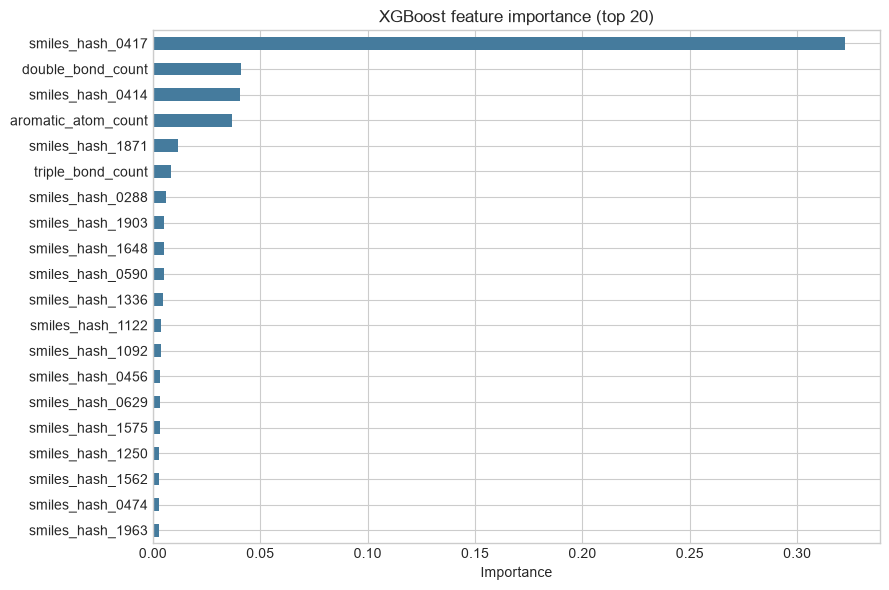

In [16]:
# ＊〜 XGBoostの特徴量重要度を列名と対応させて確認します 〜＊

# 欠損indicatorを含む補完後の記述子名を取得する
imputed_descriptor_names = list(
    final_imputer.get_feature_names_out(descriptor_names)
)

# 使用方式に応じてfingerprint列名の接頭辞を決める
fingerprint_prefix = (
    "morgan_bit" if ACTIVE_FEATURE_MODE == "rdkit" else "smiles_hash"
)
# 2048個のfingerprint列へ連番の名前を付ける
fingerprint_names = [
    f"{fingerprint_prefix}_{index:04d}"
    for index in range(N_FINGERPRINT_FEATURES)
]

# 記述子名とfingerprint名を学習時と同じ順で結合する
combined_feature_names = imputed_descriptor_names + fingerprint_names
# 特徴量名とXGBoost重要度の個数が一致するか
assert len(combined_feature_names) == len(final_xgb_model.feature_importances_)

# 列名と重要度を対応させて上位20個を選ぶ
feature_importance = (
    pd.Series(
        final_xgb_model.feature_importances_,
        index=combined_feature_names,
        name="importance",
    )
    .sort_values(ascending=False)
    .head(20)
)

# 上位20特徴量と重要度を表で表示する
display(feature_importance.to_frame())
# 重要度を横棒グラフで描く
feature_importance.sort_values().plot.barh(figsize=(9, 6), color="#457b9d")
# グラフのタイトルを設定する
plt.title("XGBoost feature importance (top 20)")
# 横軸が特徴量重要度であることを示す
plt.xlabel("Importance")
# ラベルが切れないよう余白を調整する
plt.tight_layout()
# 完成した特徴量重要度グラフを表示する
plt.show()


## 13. 初心者向けの発表準備と約2分の説明文

ここでは、難しい言葉を覚えて並べるのではなく、**「何を予測したか → どのように確かめたか → どのモデルを選んだか → 結果はどうだったか」**の順で説明します。

### 13.1 話す順番

1. **課題**：SMILESから `gap_eV` を予測する。
2. **データ**：答え付きtrain 15,000件で学び、答えなしtest 4,000件を予測する。
3. **評価方法**：予測と正解の平均的なずれを表すMAEを使い、小さいモデルを良いと判断する。
4. **予測材料**：SMILESを、原子数や文字列パターンなどの数値へ変換する。
5. **確かめ方**：trainを5組に分け、学習に使わなかった組を予測する作業を5回繰り返す。
6. **モデル比較**：Extra Trees、XGBoost、両者の組み合わせを同じ分け方で比べる。
7. **結果**：OOF MAEが最も小さい候補を選び、全trainで学び直してtestを予測する。
8. **安全確認**：提出CSVの列、行数、SMILESの順番、予測値を自動検査する。

下のコードセルを実行すると、実際に選ばれた特徴量方式、モデル名、MAEを入れた説明文が表示されます。その文章を最初はそのまま読み、慣れたら自分の言葉へ少しずつ置き換えてください。

### 13.2 説明するときに見る場所

| 順番 | Notebookで見る表示 | ここで確認して話すこと |
| --- | --- | --- |
| 1 | 「指定データの安全確認」と先頭3行 | train/testの件数、入力がSMILES、答えが `gap_eV` であること |
| 2 | `Feature mode` | 実際にRDKit経路とfallback経路のどちらを使ったか |
| 3 | foldの一覧表 | 検証データが各foldで約3,000件になり、5組に分かれていること |
| 4 | モデル比較表 | `oof_mae_eV` が一番小さいモデル名と数値 |
| 5 | 予測対実測・残差グラフ | 点が斜め線に近いか、誤差が0付近に集まっているか |
| 6 | 最終チェック表 | 提出CSVの4,000行、列順、SMILES順、有限値がすべてTrueか |

> **発表時の重要な注意**：`0.3078 eV` はtrain内のOOF MAEです。答えなしtestの最終成績ではありません。また、現在の表示が `string_fallback` の場合、その特徴量をMorgan fingerprintと説明してはいけません。

### 13.3 発表前に調べておくべき内容

まずは次の「一文で説明できる状態」を目標にしてください。

| 優先度 | 調べる言葉 | 一文で説明するときの目標 |
| --- | --- | --- |
| 必須 | `gap_eV` とeV | この課題で何のエネルギー差を表す値かを配布スライドで確認し、eVがエネルギーの単位だと説明できる |
| 必須 | SMILES | 分子の原子・結合・分岐などを1行の文字列で表す方法だと説明できる |
| 必須 | MAE | 予測値と正解値の差の絶対値を平均したもので、小さいほど良いと説明できる |
| 必須 | trainとtest | trainは答え付きで学習に使い、testは答えを予測するデータだと説明できる |
| 必須 | 5-fold CVとOOF予測 | trainを5組に分け、各行をその行で学習していないモデルで予測して性能を測る方法だと説明できる |
| 必須 | 特徴量 | SMILESをモデルが計算できる数値の予測材料へ変換したものだと説明できる |
| 必須 | データリーク | 本来見てはいけない検証・testの情報が学習へ混ざり、成績が実際より良く見える問題だと説明できる |
| 余力 | Extra Trees | 多数の決定木の予測を平均するモデルだと説明できる |
| 余力 | XGBoost | 間違いを少しずつ直すように決定木を順番に追加するモデルだと説明できる |
| 余力 | fingerprint | 分子中にどのような部分構造があるかを固定長の数値で表したものだと説明できる |
| 余力 | ハイパーパラメータ | 木の本数や深さなど、人が学習前に決める設定だと説明できる |

特に `gap_eV` の物理的な意味は、一般的な説明を暗記するのではなく、**今回の配布スライドでの定義**を確認してください。SMILESについては、`C`・`N`・`O`・`F`、`=`、`#`、括弧、数字が何を表すかまで調べると、特徴量の説明がしやすくなります。

### 13.4 よく聞かれる質問と短い答え

- **なぜMAEを使いましたか？**  
  課題で指定された評価指標であり、予測が正解から平均して何eVずれたかを同じ単位で説明できるためです。

- **なぜtrainを5組に分けましたか？**  
  testの答えを使わず、未知データに対する性能をtrain内で見積もるためです。

- **なぜ同じSMILESを学習側と検証側に分けませんか？**  
  同じ分子を一度見たモデルにその分子を予測させると、性能が実際より良く見えるためです。

- **なぜXGBoostを選びましたか？**  
  有名だからではなく、同じ5-foldで比較した候補の中でOOF MAEが最も小さかったためです。

- **なぜ2種類のモデルを試しましたか？**  
  異なる学習方法を公平に比べ、単体と組み合わせのどれが良いかを確認するためです。

- **今後は何を改善しますか？**  
  まずRDKit特徴量を同じfoldで比較し、その後に木の深さなどを一度に1項目ずつ変更します。

- **特徴量重要度が高ければ原因だと言えますか？**  
  言えません。重要度はモデルが予測時によく使ったことを示しますが、物理的な原因の証明ではありません。

### 13.5 初心者向け説明コードの役割

*〜 実際に使った特徴量方式・採用モデル・OOF MAEを、やさしい説明文へ自動挿入します 〜*

- **入力**：実行結果
- **処理**：専門用語を短い説明へ言い換え、モデル名とMAEを文章へ入れます
- **出力**：初心者でも流れを追って読める発表文を表示します


In [17]:
# ＊〜 実測結果を使い、初心者向けの約2分説明文を自動生成します 〜＊

# 実行時に選ばれた特徴量方式を、発表で使いやすい日本語へ言い換える
beginner_feature_description = {
    "rdkit": (
        "SMILESをRDKitで分子構造として読み取り、"
        "分子全体の特徴と部分構造の有無を数値にしたもの"
    ),
    "string_fallback": (
        "SMILESの長さや原子の数と、"
        "1〜5文字の並びを数値にしたもの"
    ),
}[ACTIVE_FEATURE_MODE]

# コード内のモデル名を、発表で読みやすい表記へ言い換える
beginner_model_name = {
    "extra_trees": "Extra Trees",
    "xgboost": "XGBoost",
    "ensemble": "Extra TreesとXGBoostの組み合わせ",
}[selected_model_name]

# 実際の特徴量方式・採用モデル・MAEを入れた説明文を作る
beginner_explanation = f"""
今回の課題は、分子を文字で表したSMILESから、
gap_eVという値を予測することです。
答え付きの学習データ15,000件でモデルを学習し、
答えのないtestデータ4,000件を予測しました。

予測の良さはMAEで評価しました。
MAEは予測値と正解値が平均してどれくらいずれたかを表し、
値が小さいほど良い結果です。

モデルへSMILESをそのまま渡すのではなく、
{beginner_feature_description}を予測材料にしました。

性能を公平に確かめるため、学習データを5組に分け、
4組で学習して残り1組を予測する作業を5回繰り返しました。
このとき、同じSMILESが学習側と確認側の両方へ
入らないようにしました。

Extra TreesとXGBoost、2つの予測の組み合わせを比べた結果、
採用したモデルは{beginner_model_name}で、
OOF MAEは{selected_oof_mae:.4f} eVでした。
これはtrain内で見積もった値で、testの最終成績ではありません。

最後に、選んだモデルを全学習データで学び直し、
testデータ4,000件の予測をsubmission.csvへ保存しました。
工夫した点は、情報の漏れを防いだ比較と、
提出ファイルの行数や並び順を自動確認したことです。
""".strip()

# 初心者向けの発表文をNotebookへ表示する
print(beginner_explanation)


今回の課題は、分子を文字で表したSMILESから、
gap_eVという値を予測することです。
答え付きの学習データ15,000件でモデルを学習し、
答えのないtestデータ4,000件を予測しました。

予測の良さはMAEで評価しました。
MAEは予測値と正解値が平均してどれくらいずれたかを表し、
値が小さいほど良い結果です。

モデルへSMILESをそのまま渡すのではなく、
SMILESの長さや原子の数と、1〜5文字の並びを数値にしたものを予測材料にしました。

性能を公平に確かめるため、学習データを5組に分け、
4組で学習して残り1組を予測する作業を5回繰り返しました。
このとき、同じSMILESが学習側と確認側の両方へ
入らないようにしました。

Extra TreesとXGBoost、2つの予測の組み合わせを比べた結果、
採用したモデルはXGBoostで、
OOF MAEは0.2494 eVでした。
これはtrain内で見積もった値で、testの最終成績ではありません。

最後に、選んだモデルを全学習データで学び直し、
testデータ4,000件の予測をsubmission.csvへ保存しました。
工夫した点は、情報の漏れを防いだ比較と、
提出ファイルの行数や並び順を自動確認したことです。


## 14. 当日配布の正解付きtestで最終MAEを計算する

*〜 正解ファイルが存在する場合だけ、SMILESで照合して最終MAEを計算します 〜*

**このセルで行うこと**

- **入力**：当日配布予定の `qm9_bandgap_test_with_answer.csv` と凍結済み `submission.csv`
- **処理**：ファイルがあれば列・行数・SMILES一致を検査してMAEを計算します
- **出力**：正解がなければ安全にskipし、あれば最終MAEを表示します

**この結果を見てモデルや重みを再調整しません。**


In [18]:
# ＊〜 当日配布の正解がある場合だけ、凍結済み提出の最終MAEを計算します 〜＊

# 正解CSVがまだない場合の処理へ分岐する
if not ANSWER_PATH.exists():
    # 正解CSVがないため評価を行わなかったことを表示する
    print(
        f"{ANSWER_PATH} はまだありません。"
        "正解配布後にNotebookを先頭から順に確認してください。"
    )
# 正解CSVがある場合だけ最終評価へ進む
else:
    # 当日配布の正解CSVを読み込む
    answer = pd.read_csv(ANSWER_PATH)
    # 正解CSVの列名と列順がsmiles, gap_eVか
    assert answer.columns.tolist() == ["smiles", TARGET]
    # 正解CSVがtestと同じ4,000行か
    assert len(answer) == len(test) == 4_000
    # 正解CSVのSMILESが重複せず1分子1行か
    assert answer["smiles"].is_unique
    # 正解gap_eVがすべて有限の数値か
    assert np.isfinite(answer[TARGET].to_numpy(dtype=float)).all()

    # SMILESをキーに正解値と凍結済み予測を1対1で結合する
    evaluated = answer.merge(
        saved_submission,
        on="smiles",
        how="inner",
        suffixes=("_true", "_pred"),
        validate="one_to_one",
    )
    # 結合後も全4,000分子が欠けていないか
    assert len(evaluated) == 4_000

    # 正解値と提出予測から最終test MAEを計算する
    final_test_mae = mean_absolute_error(
        evaluated[f"{TARGET}_true"],
        evaluated[f"{TARGET}_pred"],
    )
    # 最終test MAEをeV単位で表示する
    print(f"Final test MAE: {final_test_mae:.6f} eV")
    # test正解を再調整に使わない方針を表示する
    print("この値を使った再調整は行いません。")


qm9_bandgap_test_with_answer.csv はまだありません。正解配布後にNotebookを先頭から順に確認してください。


## 15. 最終自動チェック

*〜 入力、fold、予測、提出物、モデル数を最後にまとめて再検査します 〜*

**このセルで行うこと**

- **入力**：このNotebookで作った主要変数と `submission.csv`
- **処理**：完了条件をbool表へまとめ、1つでも失敗すれば停止します
- **出力**：全項目がTrueのチェック表を表示します


In [19]:
# ＊〜 Notebook全体の完了条件をまとめて自動検査します 〜＊

# Notebookの主要な完了条件を真偽値一覧にまとめる
final_checks = pd.Series(
    {
        "trainは15,000行": len(train) == 15_000,
        "testは4,000行": len(test) == 4_000,
        "目的変数はgap_eV": TARGET == "gap_eV",
        "seedは8": SEED == 8,
        "5-foldを使用": len(fold_splits) == 5,
        "全行にOOF予測あり": np.isfinite(selected_oof_prediction).all(),
        "baselineよりOOF MAEが低い": selected_oof_mae < baseline_mae,
        "基モデルは最大3個": len(BASE_MODEL_NAMES) <= 3,
        "提出CSVが存在": SUBMISSION_PATH.exists(),
        "提出CSVは4,000行": len(saved_submission) == 4_000,
        "提出列はsmiles,gap_eV": saved_submission.columns.tolist()
        == ["smiles", TARGET],
        "提出SMILES順が一致": saved_submission["smiles"].equals(test["smiles"]),
        "提出予測は全て有限": np.isfinite(
            saved_submission[TARGET].to_numpy(dtype=float)
        ).all(),
    },
    name="passed",
)

# 各完了条件がTrueかを表で表示する
display(final_checks.to_frame())
# すべての完了条件がTrueか
assert final_checks.all(), "最終チェックに失敗した項目があります。"
# 全条件に合格したことを表示する
print("全ての最終チェックに合格しました。")


全ての最終チェックに合格しました。


,passed
"trainは15,000行",True
"testは4,000行",True
目的変数はgap_eV,True
seedは8,True
5-foldを使用,True
全行にOOF予測あり,True
baselineよりOOF MAEが低い,True
基モデルは最大3個,True
提出CSVが存在,True
"提出CSVは4,000行",True


## 16. 提出前チェックリストと次に試す改善

### 提出前チェック

- [x] 指定されたtrain/test CSVだけを使用した
- [x] 外部データ、LLM、NNP、事前学習モデルを使っていない
- [x] seed、目的変数、CV、評価指標、特徴量、ハイパーパラメータを明記した
- [x] 同一SMILES groupを学習foldと検証foldへ分けていない
- [x] 欠損補完を各foldの学習部分だけでfitした
- [x] testの正解をモデル・特徴量・混合比の選択に使っていない
- [x] Extra TreesとXGBoostの設定をtrain内OOF MAEだけで調整した
- [x] 提出候補はExtra Trees、XGBoost、ensembleの最大3系統
- [x] `submission.csv` は `smiles,gap_eV` の2列、4,000件、元test順
- [x] 使用した特徴量方式とfallbackの制約を明記した

### 次に試す順序

1. ネットワーク利用可能時にlesson_9内で `uv add rdkit` を実行し、RDKit経路を同じfoldで比較する。
2. RDKit利用時にMorganのradius 2/3、bit数2,048/4,096を一度に1項目だけ比較する。
3. XGBoostの `max_leaves` を96/128/160で比較し、計算時間も記録する。
4. Extra Treesの `min_samples_leaf` 3/4/5を複数seedで確認する。
5. 複数seedでも平均MAEが改善するか確認する。
6. RDKit利用時はBemis–Murcko scaffold分割を補助評価として追加する。
7. 変更の採否はtest正解ではなく、共通OOF MAEとfold標準偏差で決める。
